# Airline Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from math import radians, sin, cos, asin, sqrt

conn = sqlite3.connect("../data/flights.db")

# Load offers
df = pd.read_sql("SELECT * FROM offers", conn)
print("offers loaded:", df.shape)

# Merge in airline type from the airlines table
airlines_df = pd.read_sql("SELECT iata AS airline, type AS airline_type FROM airlines", conn)
df = df.merge(airlines_df, on="airline", how="left")

# Quick coverage check
n_total = len(df)
n_typed = df["airline_type"].notna().sum()
print(f"airline_type populated for {n_typed}/{n_total} rows ({n_typed/n_total:.1%})")

# Merge in lat/long from airports for distance computation
airports_df = pd.read_sql("SELECT iata, latitude, longitude FROM airports", conn)
df = df.merge(
    airports_df.rename(columns={"iata": "origin_airport", "latitude": "origin_latitude", "longitude": "origin_longitude"}),
    on="origin_airport", how="left",
)
df = df.merge(
    airports_df.rename(columns={"iata": "destination_airport", "latitude": "destination_latitude", "longitude": "destination_longitude"}),
    on="destination_airport", how="left",
)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a))

df["distance_km"] = df.apply(
    lambda row: haversine_km(row["origin_latitude"], row["origin_longitude"],
                              row["destination_latitude"], row["destination_longitude"]),
    axis=1,
)

df.head()

offers loaded: (40304, 23)
airline_type populated for 34173/40304 rows (84.8%)


,id,captured_at,lead_time_days,origin,destination,origin_airport,destination_airport,airline,flight_number,departure_at,...,raw_offer,flight_class,return_at,trip_duration_days,airline_type,origin_latitude,origin_longitude,destination_latitude,destination_longitude,distance_km
0,1,2026-05-10T06:13:21.013668+00:00,18,YTO,YVR,YYZ,YVR,WS,627,2026-05-28T06:15:00-04:00,...,"{""flight_number"": ""627"", ""link"": ""/search/YYZ2...",0,2026-05-29T09:30:00-07:00,1,hybrid,43.675935,-79.629421,49.193901,-123.183998,3345.659247
1,2,2026-05-10T06:13:21.013668+00:00,15,YTO,YVR,YYZ,YVR,WS,641,2026-05-25T13:30:00-04:00,...,"{""flight_number"": ""641"", ""link"": ""/search/YYZ2...",0,2026-05-29T09:30:00-07:00,4,hybrid,43.675935,-79.629421,49.193901,-123.183998,3345.659247
2,3,2026-05-10T06:13:21.013668+00:00,12,YTO,YVR,YYZ,YVR,WS,385,2026-05-22T15:30:00-04:00,...,"{""flight_number"": ""385"", ""link"": ""/search/YYZ2...",0,2026-05-25T09:50:00-07:00,3,hybrid,43.675935,-79.629421,49.193901,-123.183998,3345.659247
3,4,2026-05-10T06:13:21.013668+00:00,19,YTO,YVR,YYZ,YVR,WS,381,2026-05-29T08:00:00-04:00,...,"{""flight_number"": ""381"", ""link"": ""/search/YYZ2...",0,2026-05-30T09:30:00-07:00,1,hybrid,43.675935,-79.629421,49.193901,-123.183998,3345.659247
4,5,2026-05-10T06:13:21.013668+00:00,11,YTO,YVR,YYZ,YVR,PD,405,2026-05-21T13:45:00-04:00,...,"{""flight_number"": ""405"", ""link"": ""/search/YYZ2...",0,2026-05-30T09:30:00-07:00,9,hybrid,43.675935,-79.629421,49.193901,-123.183998,3345.659247


## Price by Airline Type

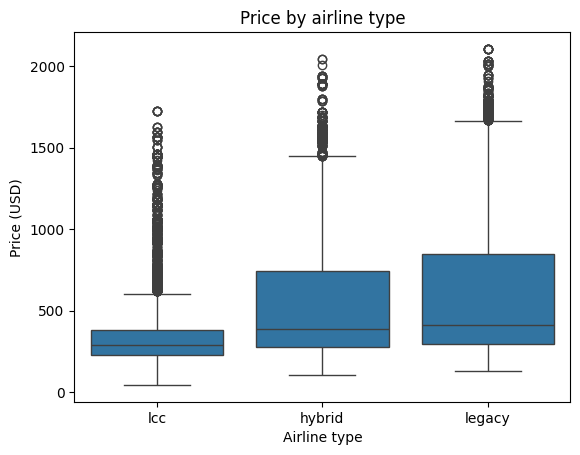

In [2]:
df_typed = df.dropna(subset=["airline_type"])

sns.boxplot(
    data=df_typed,
    x="airline_type",
    y="price",
    order=["lcc", "hybrid", "legacy"],
)
plt.title("Price by airline type")
plt.xlabel("Airline type")
plt.ylabel("Price (USD)")
plt.show()

## Price vs Distance, by Airline Type

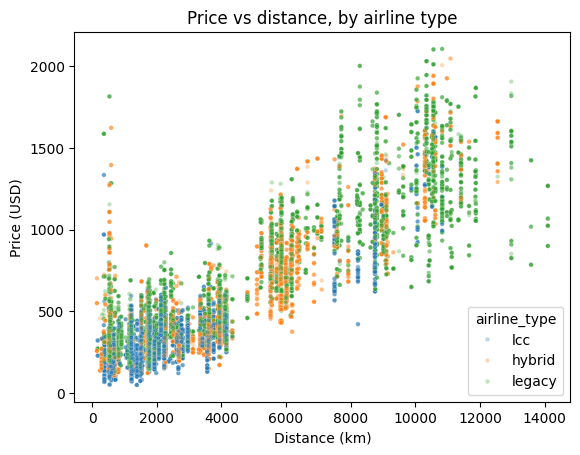

In [3]:
sns.scatterplot(
    data=df_typed,
    x="distance_km",
    y="price",
    hue="airline_type",
    hue_order=["lcc", "hybrid", "legacy"],
    s=10,
    alpha=0.3,
)
plt.title("Price vs distance, by airline type")
plt.xlabel("Distance (km)")
plt.ylabel("Price (USD)")
plt.show()

## Price by Airline (Top 15)

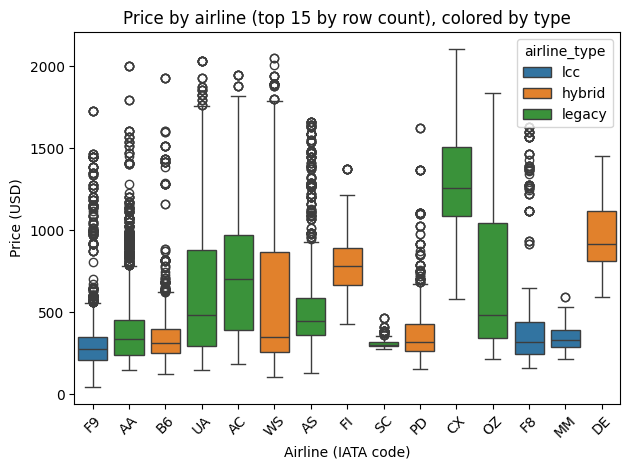

In [4]:
top_airlines = df_typed["airline"].value_counts().head(15).index.tolist()
df_top = df_typed[df_typed["airline"].isin(top_airlines)]

sns.boxplot(
    data=df_top,
    x="airline",
    y="price",
    hue="airline_type",
    hue_order=["lcc", "hybrid", "legacy"],
    order=top_airlines,
    dodge=False,
)
plt.title("Price by airline (top 15 by row count), colored by type")
plt.xlabel("Airline (IATA code)")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()